In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
    RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


df = pd.read_pickle("train_dataset_normalized.pkl")

In [ ]:
X = df.iloc[:, ~df.columns.isin(['Прогрессия'])]
y = df['Прогрессия']

print("Информация о данных:")
print("Размер данных:", df.shape)
print(f"Признаки: {X.shape}")
print(f"Целевая переменная: {y.shape}")
print(f"Классы: {np.unique(y)}")
display(X)
y

Информация о данных:
Размер данных: (548, 19)
Признаки: (548, 18)
Целевая переменная: (548,)
Классы: [0 1]


,Число очагов,Объем очагов,Число РХ процедур,Индекс Карновского,ОВГМ,Операция,Возраст,Время метастазирования,Время реагирования,КРР,Меланома,НМРЛ,РМЖ,РП,Таргетная терапия,Химиотерапия,Без лечения,Мужчина
0,0.095238,0.008543,0.0,0.666667,0,0,0.490909,0.076249,0.165963,0,1,0,0,0,0,1,0,1
1,0.095238,0.101619,0.0,0.666667,0,0,0.690909,0.034228,-0.004219,0,0,0,0,1,0,0,0,1
2,0.476190,0.178732,0.0,0.666667,0,0,0.454545,0.203423,0.018284,1,0,0,0,0,0,1,0,0
3,0.285714,0.062950,0.2,0.666667,0,0,0.472727,0.068179,0.030942,0,0,0,1,0,1,0,0,0
4,0.476190,0.127023,0.8,0.666667,0,0,0.472727,0.012801,0.014065,0,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,0.000000,0.268885,0.0,0.500000,0,0,0.618182,0.093363,0.032349,1,0,0,0,0,0,1,0,1
544,0.857143,0.044739,0.4,0.666667,1,0,0.181818,0.115208,-0.015471,0,1,0,0,0,1,0,0,0
545,0.523810,0.214478,0.0,0.500000,0,0,0.072727,0.016836,0.028129,0,1,0,0,0,0,0,0,1
546,0.142857,0.054406,0.0,0.500000,0,0,0.545455,0.080840,0.042194,0,0,0,0,1,1,0,0,0


,Прогрессия
0,1
1,1
2,0
3,1
4,1
...,...
543,0
544,1
545,0
546,0


In [ ]:
TARGET_COL = "Прогрессия"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Распределение классов:\n", y.value_counts())

base_logreg = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

strategies = {
    "Без балансировки": Pipeline([
        ("clf", base_logreg)
    ]),
    "Balanced weights": Pipeline([
        ("clf", LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "Random Oversampling": Pipeline([
        ("ros", RandomOverSampler(random_state=42)),
        ("clf", base_logreg)
    ]),
    "SMOTE": Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", base_logreg)
    ]),
}

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

summary_rows = []
raw_scores = {metric: {} for metric in scoring.keys()}

for name, pipe in strategies.items():
    print(f"++=== Стратегия: {name} ===++")
    cv_res = cross_validate(
        pipe,
        X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    for metric in scoring.keys():
        scores = cv_res[f"test_{metric}"]
        summary_rows.append({
            "strategy": name,
            "metric": metric,
            "mean": scores.mean(),
            "std": scores.std()
        })
        raw_scores[metric][name] = scores
        print(f"{metric:>18}: {scores.mean():.4f} ± {scores.std():.4f}")

summary_df = pd.DataFrame(summary_rows)
print("\nСредние значения метрик по стратегиям:")
display(summary_df.pivot(index="strategy", columns="metric", values="mean"))


Размер X: (548, 18)
Размер y: (548,)
Распределение классов:
 Прогрессия
1    369
0    179
Name: count, dtype: int64
++=== Стратегия: Без балансировки ===++
 balanced_accuracy: 0.5752 ± 0.0197
          accuracy: 0.6933 ± 0.0293
            recall: 0.9157 ± 0.0538
         precision: 0.7113 ± 0.0093
                f1: 0.8001 ± 0.0252
++=== Стратегия: Balanced weights ===++
 balanced_accuracy: 0.6900 ± 0.0515
          accuracy: 0.6677 ± 0.0509
            recall: 0.6258 ± 0.0626
         precision: 0.8406 ± 0.0498
                f1: 0.7159 ± 0.0500
++=== Стратегия: Random Oversampling ===++
 balanced_accuracy: 0.6979 ± 0.0580
          accuracy: 0.6841 ± 0.0599
            recall: 0.6582 ± 0.0700
         precision: 0.8368 ± 0.0441
                f1: 0.7357 ± 0.0574
++=== Стратегия: SMOTE ===++
 balanced_accuracy: 0.7003 ± 0.0629
          accuracy: 0.6951 ± 0.0625
            recall: 0.6853 ± 0.0638
         precision: 0.8307 ± 0.0476
                f1: 0.7506 ± 0.0564

Средние зна

metric,accuracy,balanced_accuracy,f1,precision,recall
strategy,,,,,
Balanced weights,0.667740,0.690027,0.715945,0.840559,0.625768
Random Oversampling,0.684137,0.697928,0.735718,0.836767,0.658238
SMOTE,0.695079,0.700288,0.750596,0.830684,0.685339
Без балансировки,0.693311,0.575169,0.800149,0.711307,0.915735


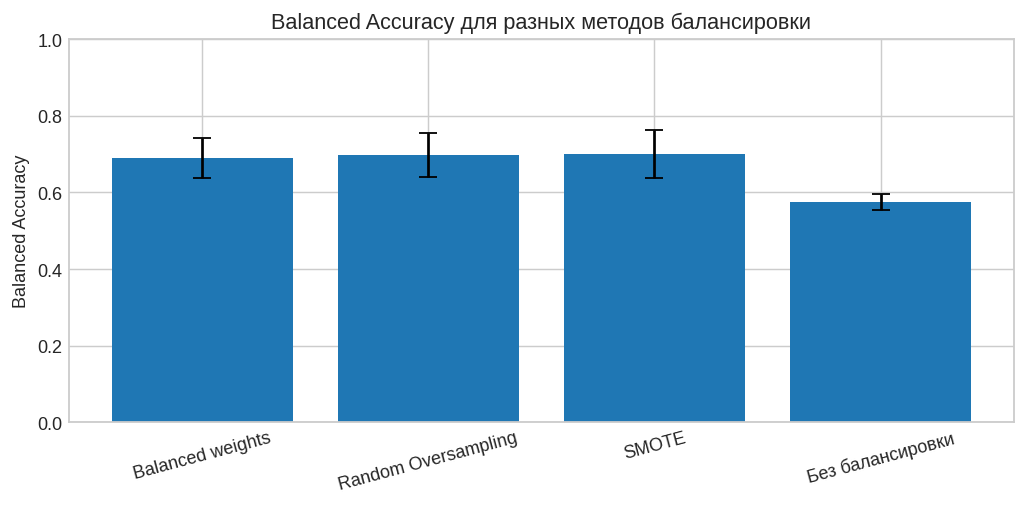

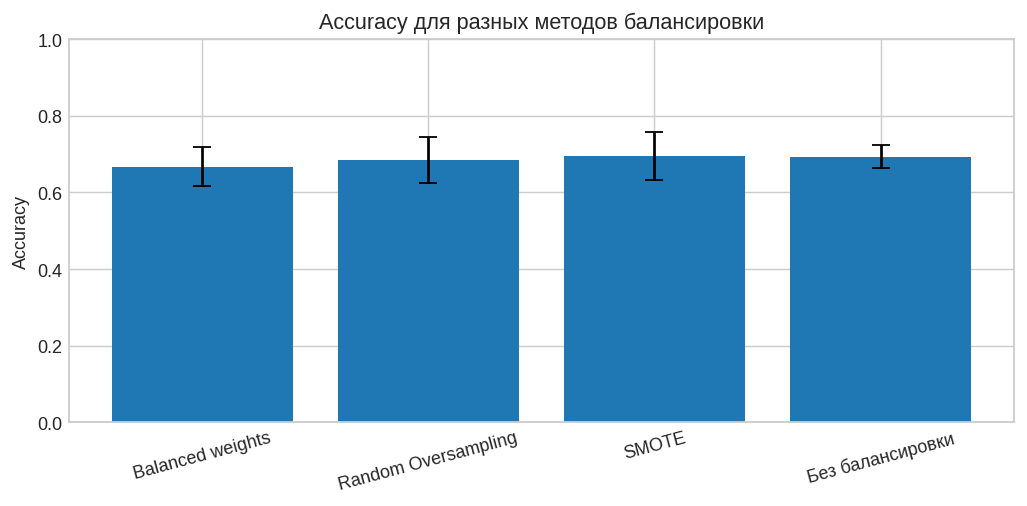

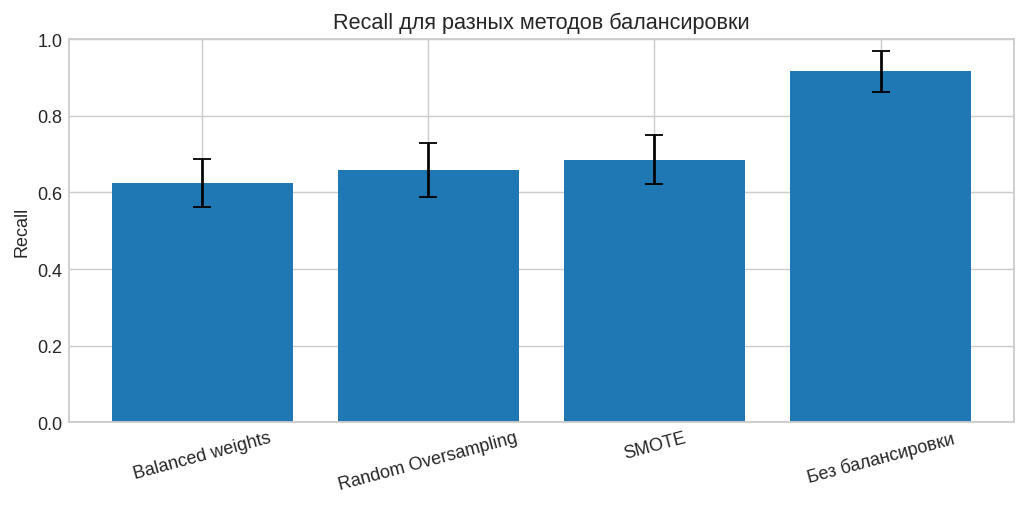

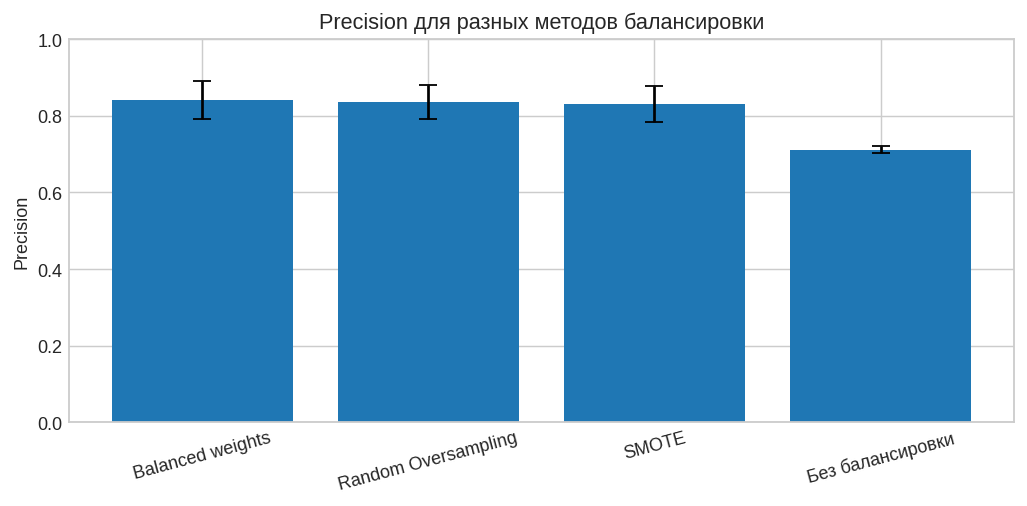

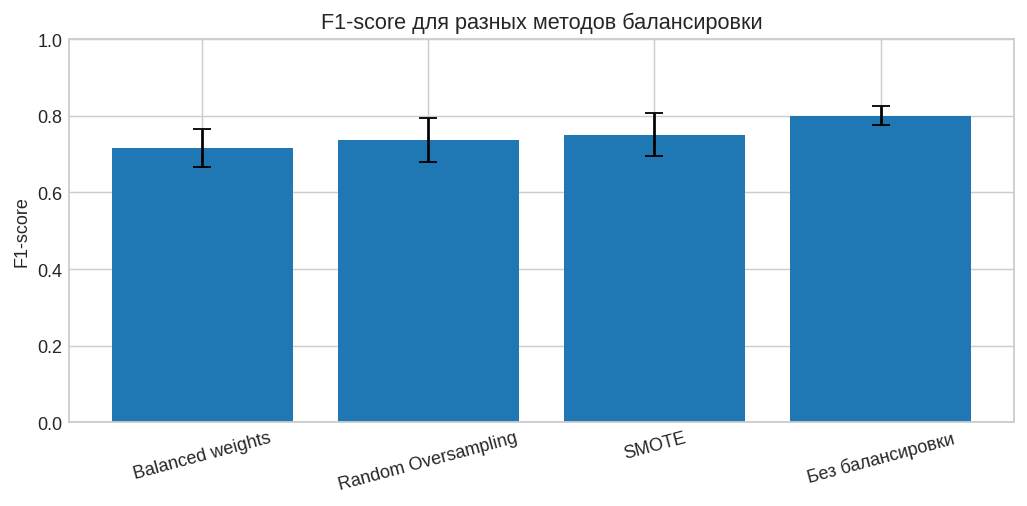

In [ ]:
metrics_order = ["balanced_accuracy", "accuracy", "recall", "precision", "f1"]
metric_titles = {
    "balanced_accuracy": "Balanced Accuracy",
    "accuracy": "Accuracy",
    "recall": "Recall",
    "precision": "Precision",
    "f1": "F1-score"
}

for metric in metrics_order:
    df_m = summary_df[summary_df["metric"] == metric].sort_values("strategy")
    plt.figure(figsize=(8, 4), dpi=130)
    plt.bar(
        df_m["strategy"],
        df_m["mean"],
        yerr=df_m["std"],
        capsize=5
    )
    plt.ylabel(metric_titles[metric])
    plt.title(f"{metric_titles[metric]} для разных методов балансировки")
    plt.ylim(0, 1)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


________________________________________________________________________________

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (438, 18)  Test: (110, 18)


In [ ]:
def make_model_name(params, index):
    d = params.get("clf__max_depth", "?")
    n = params.get("clf__n_estimators", "?")
    mf = params.get("clf__max_features", "?")
    ms = params.get("clf__min_samples_split", "?")
    ml = params.get("clf__min_samples_leaf", "?")

    return (
        f"RF_SMOTE_{index+1}"
        f"(d{d}_n{n}_mf={mf}_ms={ms}_ml={ml})"
    )


In [ ]:
from scipy.stats import randint

pipe_rf = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

param_distributions = {
    "clf__n_estimators": randint(50, 301),
    "clf__max_depth": randint(3, 16),
    "clf__min_samples_split": randint(2, 11),
    "clf__min_samples_leaf": randint(1, 11),
    "clf__max_features": ["sqrt", "log2", None]
}

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rand_search = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_distributions,
    n_iter=150,
    scoring="balanced_accuracy",
    n_jobs=-1,
    cv=cv_inner,
    random_state=42,
    refit=False,
    verbose=1
)


rand_search.fit(X_train, y_train)
cv_results = pd.DataFrame(rand_search.cv_results_)
cv_results_sorted = cv_results.sort_values("rank_test_score")
top5 = cv_results_sorted.head(5)

print("Топ-5 комбинаций по Balanced Accuracy (CV):")
cols_to_show = ["rank_test_score", "mean_test_score", "std_test_score", "params"]
pd.set_option("display.max_colwidth", None)
display(top5[cols_to_show])


Fitting 3 folds for each of 150 candidates, totalling 450 fits
Топ-5 комбинаций по Balanced Accuracy (CV):


,rank_test_score,mean_test_score,std_test_score,params
100,1,0.761730,0.034653,"{'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 4, 'clf__n_estimators': 291}"
39,2,0.756898,0.027586,"{'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 3, 'clf__n_estimators': 102}"
96,2,0.756898,0.024766,"{'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 9, 'clf__n_estimators': 129}"
67,4,0.756574,0.033218,"{'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 4, 'clf__n_estimators': 237}"
110,5,0.753497,0.021964,"{'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 135}"


In [ ]:
def build_rf_pipeline_with_params(params: dict):
    model = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(random_state=42))
    ])
    model.set_params(**params)
    return model

top5_results = []

for rank, (_, row) in enumerate(top5.iterrows(), start=1):
    params = row["params"]
    model = build_rf_pipeline_with_params(params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    top5_results.append({
        "Модель (rank)": rank,
        "Balanced Accuracy": bal_acc,
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "F1": f1,
        "Параметры": params
    })

results_top5_df = pd.DataFrame(top5_results)

results_top5_df["Модель"] = [
    make_model_name(params, i)
    for i, params in enumerate(results_top5_df["Параметры"])
]

print("Результаты 5 лучших моделей на тестовых данных:")
display(results_top5_df[[
    "Модель",
    "Balanced Accuracy",
    "Accuracy",
    "Recall",
    "Precision",
    "F1"
]])


Результаты 5 лучших моделей на тестовых данных:


,Модель,Balanced Accuracy,Accuracy,Recall,Precision,F1
0,RF_SMOTE_1(d3_n291_mf=log2_ms=4_ml=2),0.686562,0.645455,0.567568,0.857143,0.682927
1,RF_SMOTE_2(d3_n102_mf=sqrt_ms=3_ml=3),0.693694,0.645455,0.554054,0.872340,0.677686
2,RF_SMOTE_3(d3_n129_mf=sqrt_ms=9_ml=4),0.700450,0.654545,0.567568,0.875000,0.688525
3,RF_SMOTE_4(d3_n237_mf=log2_ms=4_ml=5),0.700450,0.654545,0.567568,0.875000,0.688525
4,RF_SMOTE_5(d3_n135_mf=sqrt_ms=10_ml=4),0.714339,0.663636,0.567568,0.893617,0.694215


=== Топ стратегий балансировки (логистическая регрессия) по Balanced Accuracy (CV) ===


,strategy,metric,mean,std
15,SMOTE,balanced_accuracy,0.700288,0.062946
10,Random Oversampling,balanced_accuracy,0.697928,0.058030
5,Balanced weights,balanced_accuracy,0.690027,0.051454
0,Без балансировки,balanced_accuracy,0.575169,0.019662



Лучшая стратегия балансировки (Задача 1): SMOTE (Balanced Accuracy CV = 0.7003 ± 0.0629)

=== Топ-5 моделей RandomForest + SMOTE по Balanced Accuracy (на тесте) ===


,Модель (rank),Balanced Accuracy,Accuracy,Recall,Precision,F1
4,5,0.714339,0.663636,0.567568,0.893617,0.694215
3,4,0.700450,0.654545,0.567568,0.875000,0.688525
2,3,0.700450,0.654545,0.567568,0.875000,0.688525
1,2,0.693694,0.645455,0.554054,0.872340,0.677686
0,1,0.686562,0.645455,0.567568,0.857143,0.682927


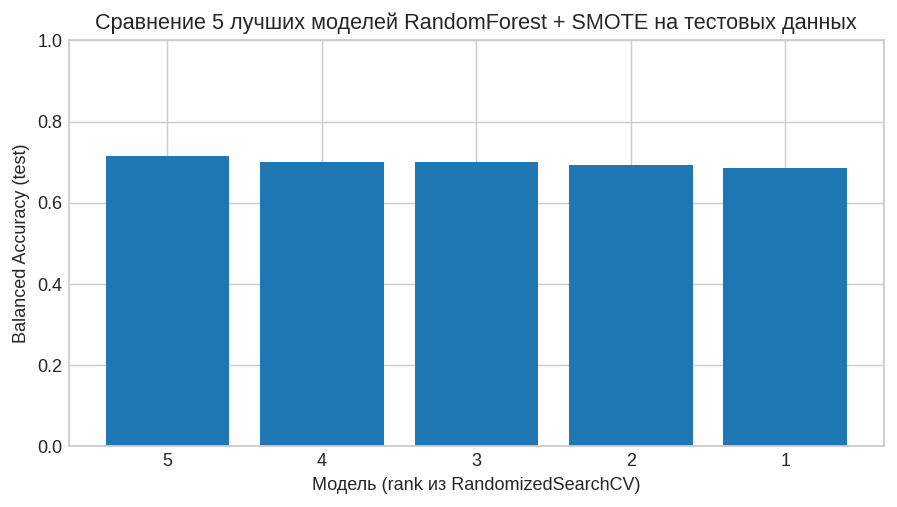


=== Окончательная лучшая модель (RandomForest + SMOTE) ===
Balanced Accuracy (test): 0.7143
Accuracy (test):           0.6636
Recall (test):             0.5676
Precision (test):          0.8936
F1 (test):                 0.6942

Лучшие найденные параметры RandomForest:
  clf__max_depth: 3
  clf__max_features: sqrt
  clf__min_samples_leaf: 4
  clf__min_samples_split: 10
  clf__n_estimators: 135

=== Classification report (лучшая модель) ===
              precision    recall  f1-score   support

           0     0.4921    0.8611    0.6263        36
           1     0.8936    0.5676    0.6942        74

    accuracy                         0.6636       110
   macro avg     0.6928    0.7143    0.6602       110
weighted avg     0.7622    0.6636    0.6720       110



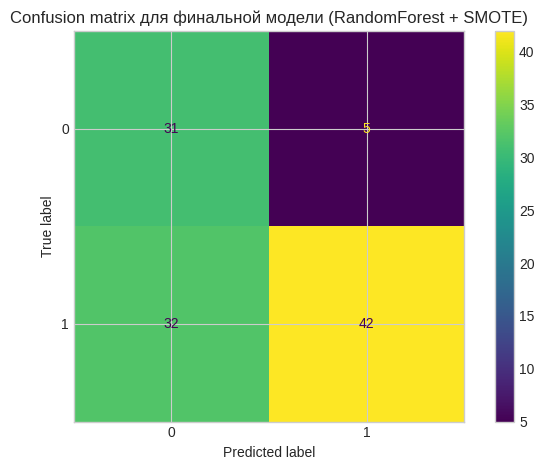


Финальная модель сохранена в файл: best_model_rf_smote.pkl


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)
import joblib


print("=== Топ стратегий балансировки (логистическая регрессия) по Balanced Accuracy (CV) ===")
bal_acc_df = (
    summary_df[summary_df["metric"] == "balanced_accuracy"]
    .sort_values("mean", ascending=False)
)
display(bal_acc_df)

best_bal_strategy = bal_acc_df.iloc[0]
print(
    f"\nЛучшая стратегия балансировки (Задача 1): "
    f"{best_bal_strategy['strategy']} "
    f"(Balanced Accuracy CV = {best_bal_strategy['mean']:.4f} ± {best_bal_strategy['std']:.4f})"
)


print("\n=== Топ-5 моделей RandomForest + SMOTE по Balanced Accuracy (на тесте) ===")
results_top5_sorted = results_top5_df.sort_values("Balanced Accuracy", ascending=False)
display(results_top5_sorted[[
    "Модель (rank)",
    "Balanced Accuracy",
    "Accuracy",
    "Recall",
    "Precision",
    "F1"
]])


plt.figure(figsize=(7, 4), dpi=130)
plt.bar(
    results_top5_sorted["Модель (rank)"].astype(str),
    results_top5_sorted["Balanced Accuracy"]
)
plt.xlabel("Модель (rank из RandomizedSearchCV)")
plt.ylabel("Balanced Accuracy (test)")
plt.title("Сравнение 5 лучших моделей RandomForest + SMOTE на тестовых данных")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

best_row = results_top5_df.loc[
    results_top5_df["Balanced Accuracy"].idxmax()
]
best_params = best_row["Параметры"]

print("\n=== Окончательная лучшая модель (RandomForest + SMOTE) ===")
print(f"Balanced Accuracy (test): {best_row['Balanced Accuracy']:.4f}")
print(f"Accuracy (test):           {best_row['Accuracy']:.4f}")
print(f"Recall (test):             {best_row['Recall']:.4f}")
print(f"Precision (test):          {best_row['Precision']:.4f}")
print(f"F1 (test):                 {best_row['F1']:.4f}")
print("\nЛучшие найденные параметры RandomForest:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

final_model = build_rf_pipeline_with_params(best_params)
final_model.fit(X_train, y_train)


y_pred_final = final_model.predict(X_test)

print("\n=== Classification report (лучшая модель) ===")
print(classification_report(y_test, y_pred_final, digits=4))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion matrix для финальной модели (RandomForest + SMOTE)")
plt.tight_layout()
plt.show()


model_path = "best_model_rf_smote.pkl"
joblib.dump(final_model, model_path)
print(f"\nФинальная модель сохранена в файл: {model_path}")


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Модель
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Обучение
gb.fit(X_train, y_train)

# Предсказания
y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Accuracy: {accuracy_gb:.4f}")



Gradient Boosting Accuracy: 0.7182


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np

gb = GradientBoostingClassifier(random_state=42)

param_distributions = {
    "n_estimators": np.arange(0, 900, 50),
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.6, 0.8, 1.0]
}

rnd_search = RandomizedSearchCV(
    gb,
    param_distributions=param_distributions,
    n_iter=40,          # ← количество случайных наборов параметров
    scoring='accuracy', # ← метрика
    cv=5,               # ← 5-fold cross-validation
    n_jobs=-1,          # ← использовать все ядра
    random_state=42
)

rnd_search.fit(X, y)

print("Лучшие параметры:", rnd_search.best_params_)
print("Лучшая точность:", rnd_search.best_score_)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Лучшие параметры: {'subsample': 0.6, 'n_estimators': np.int64(600), 'max_depth': 5, 'learning_rate': 0.01}
Лучшая точность: 0.7173144286905755
